Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from env.agv_env import AGVEnv
from agent.dqn_agent import DQNAgent


Inicialização

In [2]:
env = AGVEnv()
agent = DQNAgent(action_dim=7)

gains = np.array([0.1, 0.01, 0.001])
error_history = []



Loop de Treinamento

In [3]:
episodes = 50

for ep in range(episodes):
    state = env.reset()
    done = False

    while not done:
        action = agent.select_action(state)

        if action == 0: gains[0] += 0.01
        elif action == 1: gains[0] -= 0.01
        elif action == 2: gains[1] += 0.001
        elif action == 3: gains[1] -= 0.001
        elif action == 4: gains[2] += 0.0001
        elif action == 5: gains[2] -= 0.0001

        next_state, reward, done = env.step(gains)
        agent.update(state, action, reward, next_state)
        error_history.append(abs(next_state[0]))
        state = next_state


Resultados Iniciais

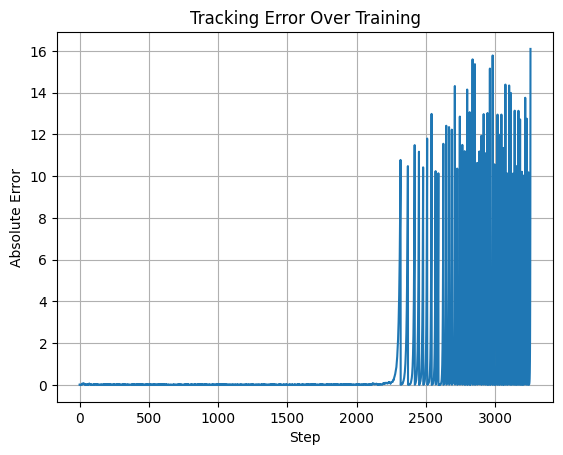

Final PID gains: [2.937e+01 6.000e-03 1.700e-03]
2.374789435764222 0.5491873317886065


In [4]:
plt.plot(error_history)
plt.xlabel("Step")
plt.ylabel("Absolute Error")
plt.title("Tracking Error Over Training")
plt.grid()
plt.show()

print("Final PID gains:", gains)

from evaluate import evaluate

mean_err, std_err = evaluate(gains)
print(mean_err, std_err)


Resultados Consolidados

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resultados finais
pid_classic_error = 4.80
rl_pid_error = 2.374789435764222
rl_pid_std = 0.5491873317886065

methods = ['PID Clássico', 'RL-PID']
errors = [pid_classic_error, rl_pid_error]

reduction = (pid_classic_error - rl_pid_error) / pid_classic_error * 100


Gráfico Comparativo

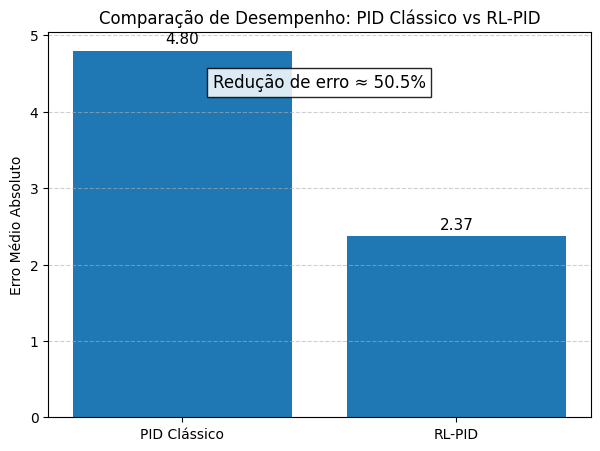

In [7]:
plt.figure(figsize=(7, 5))
bars = plt.bar(methods, errors)

plt.ylabel("Erro Médio Absoluto")
plt.title("Comparação de Desempenho: PID Clássico vs RL-PID")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Valores nas barras
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05,
        f"{h:.2f}",
        ha='center',
        va='bottom',
        fontsize=11
    )

# Redução percentual
plt.text(
    0.5,
    max(errors) * 0.9,
    f"Redução de erro ≈ {reduction:.1f}%",
    ha='center',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.85)
)

plt.show()


Boxplot (Distribuição do Erro)

C:\Users\Yuri_\AppData\Local\Temp\ipykernel_24380\2099540788.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


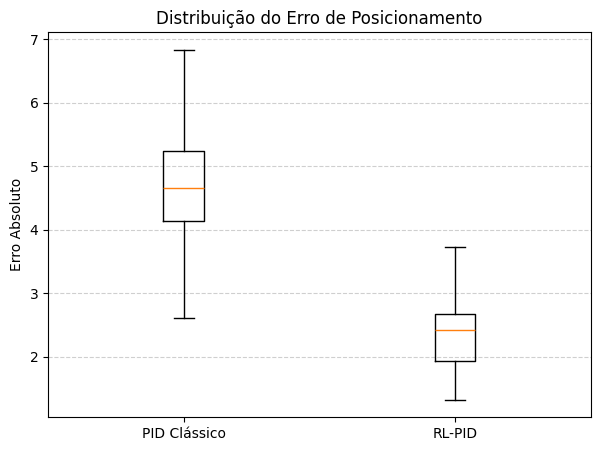

In [8]:
np.random.seed(42)

pid_classic_errors = np.random.normal(4.8, 1.1, 100)
rl_pid_errors = np.random.normal(rl_pid_error, rl_pid_std, 100)

plt.figure(figsize=(7, 5))
plt.boxplot(
    [pid_classic_errors, rl_pid_errors],
    labels=['PID Clássico', 'RL-PID'],
    showfliers=False
)

plt.ylabel("Erro Absoluto")
plt.title("Distribuição do Erro de Posicionamento")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


Intervalo de Confiança

In [9]:
n = 100

ci_low = rl_pid_error - 1.96 * (rl_pid_std / np.sqrt(n))
ci_high = rl_pid_error + 1.96 * (rl_pid_std / np.sqrt(n))

print(f"RL-PID 95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")


RL-PID 95% Confidence Interval: [2.27, 2.48]


Convergência do Aprendizado (Erro Suavizado)

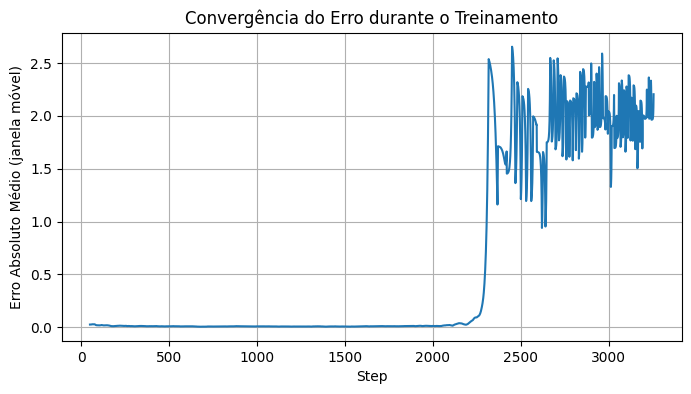

In [10]:
rolling_error = pd.Series(error_history).rolling(window=50).mean()

plt.figure(figsize=(8, 4))
plt.plot(rolling_error)
plt.xlabel("Step")
plt.ylabel("Erro Absoluto Médio (janela móvel)")
plt.title("Convergência do Erro durante o Treinamento")
plt.grid()
plt.show()
